<a href="https://colab.research.google.com/github/vaniajou/Sistem-Peringatan-Dini-Kegagalan-Siswa/blob/main/Multi_Class_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score

df = pd.read_excel('Book1.xlsx')

def buat_label(nilai):
    if nilai <= 9: return 0
    elif nilai <= 14: return 1
    else: return 2

df['Label_Multi'] = df['G3'].apply(buat_label)

df_model = df.drop(['G1', 'G2', 'G3', 'Label_Multi'], axis=1)

le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model
y = df['Label_Multi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

softmax_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_reg.fit(X_train_scaled, y_train)

ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_model.fit(X_train_scaled, y_train)

ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=1000))
ovo_model.fit(X_train_scaled, y_train)

print("HASIL AKURASI MULTI-CLASS")
print(f"Akurasi Softmax Regression : {accuracy_score(y_test, softmax_reg.predict(X_test_scaled)):.2f}")
print(f"Akurasi One-vs-Rest (OvR)  : {accuracy_score(y_test, ovr_model.predict(X_test_scaled)):.2f}")
print(f"Akurasi One-vs-One (OvO)   : {accuracy_score(y_test, ovo_model.predict(X_test_scaled)):.2f}")

HASIL AKURASI MULTI-CLASS
Akurasi Softmax Regression : 0.56
Akurasi One-vs-Rest (OvR)  : 0.51
Akurasi One-vs-One (OvO)   : 0.54


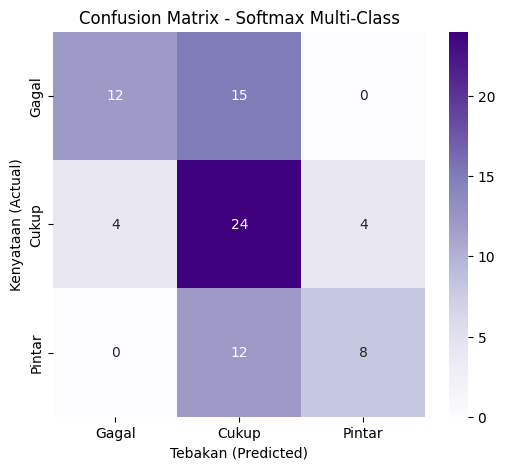

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_best = softmax_reg.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Gagal', 'Cukup', 'Pintar'],
            yticklabels=['Gagal', 'Cukup', 'Pintar'])

plt.title('Confusion Matrix - Softmax Multi-Class')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan (Predicted)')
plt.show()